In [ ]:
from dotenv import load_dotenv
from matplotlib.dates import DateFormatter
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [4]:
load_dotenv()
filename = os.environ.get('SHEET_ID')
filename

'leetcode_bakunobu.csv'

In [5]:
df = pd.read_csv(
    os.path.join('data', filename)
    )

df.head(20)

,date,rating,Easy,Med,Hard,Total
0,22-10-2025,343797,4,0,0,4
1,23-10-2025,334441,2,0,0,2
2,24-10-2025,333087,1,0,0,1
3,25-10-2025,330358,1,1,0,2
4,26-10-2025,330358,0,1,0,1
5,27-10-2025,327552,2,1,0,3
6,28-10-2025,327552,1,0,0,1
7,29-10-2025,327552,1,0,0,1
8,30-10-2025,320628,2,0,0,2
9,31-10-2025,320628,3,0,0,3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    40 non-null     object
 1   rating  40 non-null     int64 
 2   Easy    40 non-null     int64 
 3   Med     40 non-null     int64 
 4   Hard    40 non-null     int64 
 5   Total   40 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 2.0+ KB


In [7]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [8]:
df.head(20)

,date,rating,Easy,Med,Hard,Total
0,2025-10-22,343797,4,0,0,4
1,2025-10-23,334441,2,0,0,2
2,2025-10-24,333087,1,0,0,1
3,2025-10-25,330358,1,1,0,2
4,2025-10-26,330358,0,1,0,1
5,2025-10-27,327552,2,1,0,3
6,2025-10-28,327552,1,0,0,1
7,2025-10-29,327552,1,0,0,1
8,2025-10-30,320628,2,0,0,2
9,2025-10-31,320628,3,0,0,3


In [19]:
mask = (df['date']>=pd.to_datetime('2025-11-01')) & (df['date']<=pd.to_datetime('2025-11-30'))
df = df.loc[mask].sort_values('date')

In [20]:
df['rate_lag'] = df['rating'].shift(1)
df['problem_lag'] = df['Total'].cumsum()

df['rate_diff'] = df['rate_lag'] - df['rating']
df['rate_diff2'] = df['rate_diff'].cumsum()

In [22]:
df.loc[mask].agg(
    num_problems=('Total', 'sum'),
)

,Total
num_problems,83


In [23]:
df.loc[mask].iloc[0, 1] - df.loc[mask].iloc[-1, 1]

np.int64(88009)

In [ ]:
filename = 'my_file.png'
folder = 'img'
savepath = os.path.join(
    os.path.getcwd(),
    folder,
    filename
)

In [ ]:
def plot_progress(
                df,
                start_date:str,
                end_date:str,
                filename:str,
                folder:str='img'
                ):
        mask = (df['date']>=pd.to_datetime(start_date)) & (df['date']<=pd.to_datetime(end_date))
        df = df.loc[mask].sort_values('date')

        df['rate_lag'] = df['rating'].shift(1)
        df['problem_lag'] = df['Total'].cumsum()
        df['rate_diff'] = df['rate_lag'] - df['rating']
        df['rate_diff2'] = df['rate_diff'].cumsum()

        problems_solved = df.agg(
                num_problems=('Total', 'sum')
                ).values[0]
        
        pos_gainded = int(df.loc[mask].iloc[0, 1] - df.loc[mask].iloc[-1, 1])

        savepath = os.path.join(
                os.path.getcwd(),
                folder,
                filename
                )    

        # --- 2. FIGURE & LAYOUT SETUP ---
        # Set style
        plt.style.use('seaborn-v0_8')
        sns.set_palette("deep")

        # Create the main figure and the grid
        fig = plt.figure(figsize=(12, 10)) # Increased height to accommodate rows
        gs = fig.add_gridspec(2, 2)

        # --- 3. TOP PLOT (Incorporating Your Code) ---
        # Create the axis for the top row, spanning all columns
        ax1 = fig.add_subplot(gs[0, :])

        # [Your Code Adapted]: Primary Y-Axis (Left)
        sns.lineplot(x='date', y='rate_diff2', data=df, ax=ax1, color='#007acc', linewidth=2.5, label='Rating')
        ax1.set_ylabel('Positions Overtaken', fontsize=12, color='#007acc', weight='bold')
        ax1.tick_params(axis='y', labelcolor='#007acc', length=6, width=1.2)
        ax1.set_xlabel('Date', fontsize=12, weight='bold')

        # [Your Code Adapted]: Customize x-axis date formatting
        date_form = DateFormatter("%d %b")
        ax1.xaxis.set_major_formatter(date_form)
        for label in ax1.get_xticklabels():
                label.set_rotation(30)

        # [Your Code Adapted]: Secondary Y-Axis (Right)
        ax2 = ax1.twinx()
        sns.lineplot(x='date', y='problem_lag', data=df, ax=ax2, color='#d62728', linewidth=2.5, label='Problems Solved')
        ax2.set_ylabel('Problems Solved', fontsize=12, color='#d62728', weight='bold')
        ax2.tick_params(axis='y', labelcolor='#d62728', length=6, width=1.2)

        # [Your Code Adapted]: Title & Legend
        ax1.set_title('My LeetCode Progress (November 2025)', fontsize=16, weight='bold', color='darkslategray', pad=20)

        # Remove the automatic seaborn legend so we can use your custom one
        if ax1.get_legend(): ax1.get_legend().remove()
        if ax2.get_legend(): ax2.get_legend().remove()

        legend_elements = [
        Line2D([0], [0], color='#007acc', lw=2.5, label='Positions Taken'),
        Line2D([0], [0], color='#d62728', lw=2.5, label='Problems Solved')
        ]

        # Position legend
        legend = ax1.legend(
                handles=legend_elements, 
                loc='upper left',
                ncol=2,
                fontsize=11,
                frameon=True,
                fancybox=True,
                shadow=False,
                facecolor='white',
                edgecolor='gray'
                )
        legend.set_zorder(20)
        legend.get_frame().set_linewidth(1.2)

        # [Your Code Adapted]: Grid styling
        ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)
        ax1.grid(True, which='major', axis='y', linestyle='-', alpha=0.3)
        ax1.set_axisbelow(True) # Keep grid behind plot elements

        # --- 4. BOTTOM PLOTS (Side-by-Side) ---

        # Bottom Left Plot
        ax3 = fig.add_subplot(gs[1, 0])
        # Define the text and the arrow properties
        arrow_style = dict(
                arrowstyle="simple, tail_width=2.5, head_width=5, head_length=2.5",
                fc="#d62728",  # Fill color
                ec="#d62728",  # Edge color
                linewidth=0 
        )

        ax3.annotate(
                text=f'+{problems_solved} PROBLEMS SOLD',
                xy=(0.5, 0.6),        # The arrow points TO this position (the arrowhead)
                xytext=(0.5, 0.2),    # The text is drawn AT this position (the tail base)
                xycoords='axes fraction', 
                textcoords='axes fraction',
                fontsize=24,
                fontweight='bold',
                ha='center',          # Horizontal alignment of the text
                va='center',          # Vertical alignment of the text
                arrowprops=arrow_style
                )

        # 3. Clean up the plot
        ax3.set_xticks([]) # Remove x-axis ticks
        ax3.set_yticks([]) # Remove y-axis ticks
        ax3.spines['top'].set_visible(False)    # Remove the top border
        ax3.spines['right'].set_visible(False) # Remove the right border
        ax3.spines['bottom'].set_visible(False) # Remove the bottom border
        ax3.spines['left'].set_visible(False)   # Remove the left border


        # Bottom Right Plot
        ax4 = fig.add_subplot(gs[1, 1])
        arrow_style = dict(
                arrowstyle="simple, tail_width=2.5, head_width=5, head_length=2.5",
                fc="#007acc",  # Fill color
                ec="#007acc",  # Edge color
                linewidth=0
                )
        ax4.annotate(
                text=f'+{pos_gainded} POS GAINED',
                xy=(0.5, 0.6),        # The arrow points TO this position (the arrowhead)
                xytext=(0.5, 0.2),    # The text is drawn AT this position (the tail base)
                xycoords='axes fraction', 
                textcoords='axes fraction',
                fontsize=24,
                fontweight='bold',
                ha='center',          # Horizontal alignment of the text
                va='center',          # Vertical alignment of the text
                arrowprops=arrow_style
                )

        # 3. Clean up the plot
        ax4.set_xticks([]) # Remove x-axis ticks
        ax4.set_yticks([]) # Remove y-axis ticks
        ax4.spines['top'].set_visible(False)    # Remove the top border
        ax4.spines['right'].set_visible(False) # Remove the right border
        ax4.spines['bottom'].set_visible(False) # Remove the bottom border
        ax4.spines['left'].set_visible(False)   # Remove the left border

        plt.tight_layout()
        plt.subplots_adjust(top=0.92, hspace=0.4) # Add spacing between top and bottom rows
        plt.savefig(savepath)
        plt.show()

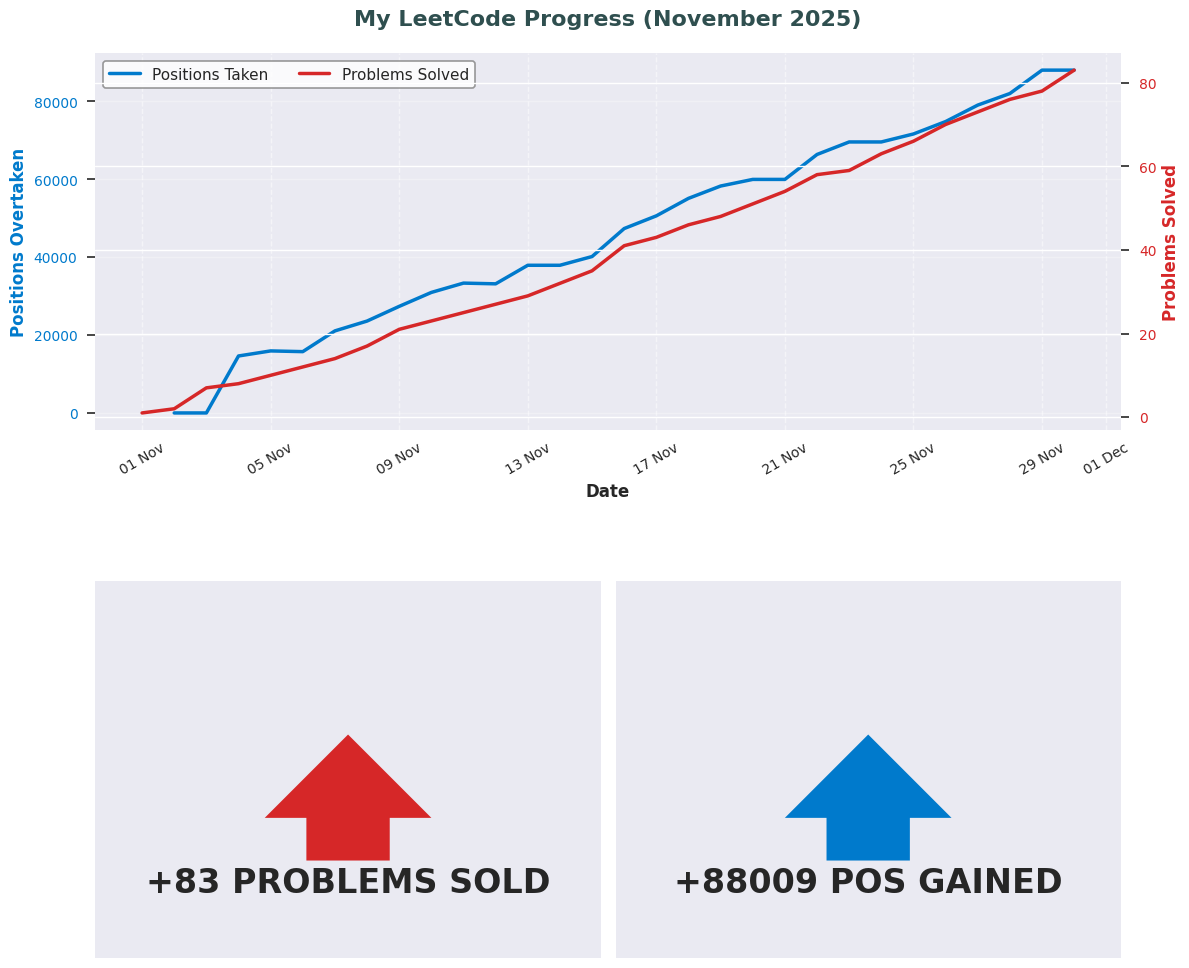

In [ ]:




# --- 2. FIGURE & LAYOUT SETUP ---
# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("deep")

# Create the main figure and the grid
fig = plt.figure(figsize=(12, 10)) # Increased height to accommodate rows
gs = fig.add_gridspec(2, 2)

# --- 3. TOP PLOT (Incorporating Your Code) ---
# Create the axis for the top row, spanning all columns
ax1 = fig.add_subplot(gs[0, :])

# [Your Code Adapted]: Primary Y-Axis (Left)
sns.lineplot(x='date', y='rate_diff2', data=df.loc[mask], ax=ax1, color='#007acc', linewidth=2.5, label='Rating')
ax1.set_ylabel('Positions Overtaken', fontsize=12, color='#007acc', weight='bold')
ax1.tick_params(axis='y', labelcolor='#007acc', length=6, width=1.2)
ax1.set_xlabel('Date', fontsize=12, weight='bold')

# [Your Code Adapted]: Customize x-axis date formatting
date_form = DateFormatter("%d %b")
ax1.xaxis.set_major_formatter(date_form)
for label in ax1.get_xticklabels():
    label.set_rotation(30)

# [Your Code Adapted]: Secondary Y-Axis (Right)
ax2 = ax1.twinx()
sns.lineplot(x='date', y='problem_lag', data=df.loc[mask], ax=ax2, color='#d62728', linewidth=2.5, label='Problems Solved')
ax2.set_ylabel('Problems Solved', fontsize=12, color='#d62728', weight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728', length=6, width=1.2)

# [Your Code Adapted]: Title & Legend
ax1.set_title('My LeetCode Progress (November 2025)', fontsize=16, weight='bold', color='darkslategray', pad=20)

# Remove the automatic seaborn legend so we can use your custom one
if ax1.get_legend(): ax1.get_legend().remove()
if ax2.get_legend(): ax2.get_legend().remove()

legend_elements = [
    Line2D([0], [0], color='#007acc', lw=2.5, label='Positions Taken'),
    Line2D([0], [0], color='#d62728', lw=2.5, label='Problems Solved')
]

# Position legend
legend = ax1.legend(handles=legend_elements, 
                    loc='upper left',
                    ncol=2,
                    fontsize=11,
                    frameon=True,
                    fancybox=True,
                    shadow=False,
                    facecolor='white',
                    edgecolor='gray')
legend.set_zorder(20)
legend.get_frame().set_linewidth(1.2)

# [Your Code Adapted]: Grid styling
ax1.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)
ax1.grid(True, which='major', axis='y', linestyle='-', alpha=0.3)
ax1.set_axisbelow(True) # Keep grid behind plot elements

# --- 4. BOTTOM PLOTS (Side-by-Side) ---

# Bottom Left Plot
ax3 = fig.add_subplot(gs[1, 0])
# Define the text and the arrow properties
arrow_style = dict(
    arrowstyle="simple, tail_width=2.5, head_width=5, head_length=2.5",
    fc="#d62728",  # Fill color
    ec="#d62728",  # Edge color
    linewidth=0 
)
ax3.annotate(
    text='+83 PROBLEMS SOLD',
    xy=(0.5, 0.6),        # The arrow points TO this position (the arrowhead)
    xytext=(0.5, 0.2),    # The text is drawn AT this position (the tail base)
    xycoords='axes fraction', 
    textcoords='axes fraction',
    fontsize=24,
    fontweight='bold',
    ha='center',          # Horizontal alignment of the text
    va='center',          # Vertical alignment of the text
    arrowprops=arrow_style
)

# 3. Clean up the plot
ax3.set_xticks([]) # Remove x-axis ticks
ax3.set_yticks([]) # Remove y-axis ticks
ax3.spines['top'].set_visible(False)    # Remove the top border
ax3.spines['right'].set_visible(False) # Remove the right border
ax3.spines['bottom'].set_visible(False) # Remove the bottom border
ax3.spines['left'].set_visible(False)   # Remove the left border


# Bottom Right Plot
ax4 = fig.add_subplot(gs[1, 1])
arrow_style = dict(
    arrowstyle="simple, tail_width=2.5, head_width=5, head_length=2.5",
    fc="#007acc",  # Fill color
    ec="#007acc",  # Edge color
    linewidth=0 
)
ax4.annotate(
    text='+88009 POS GAINED',
    xy=(0.5, 0.6),        # The arrow points TO this position (the arrowhead)
    xytext=(0.5, 0.2),    # The text is drawn AT this position (the tail base)
    xycoords='axes fraction', 
    textcoords='axes fraction',
    fontsize=24,
    fontweight='bold',
    ha='center',          # Horizontal alignment of the text
    va='center',          # Vertical alignment of the text
    arrowprops=arrow_style
)

# 3. Clean up the plot
ax4.set_xticks([]) # Remove x-axis ticks
ax4.set_yticks([]) # Remove y-axis ticks
ax4.spines['top'].set_visible(False)    # Remove the top border
ax4.spines['right'].set_visible(False) # Remove the right border
ax4.spines['bottom'].set_visible(False) # Remove the bottom border
ax4.spines['left'].set_visible(False)   # Remove the left border

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4) # Add spacing between top and bottom rows
plt.savefig('leetcode_nov_progress.png')
plt.show()